# 🏠 Analyse Exploratoire des Données — Immobilier Marocain

> **Objectif :** Explorer un jeu de données de 22 biens immobiliers répartis sur 7 villes du Maroc.  
> On cherche à comprendre les distributions des variables, les relations entre caractéristiques et prix, et identifier des tendances clés.

---

## 1. 📋 Description des colonnes et types de données

| Colonne | Type | Rôle | Définition |
|---|---|---|---|
| `surface` | Numérique continu | Feature | Surface habitable du bien en m² |
| `chambres` | Numérique discret | Feature | Nombre de chambres (1 à 6) |
| `salles_de_bain` | Numérique discret | Feature | Nombre de salles de bain |
| `kitchen` | Numérique discret | Feature | Nombre de cuisines (1 ou 2) |
| `etage` | Numérique discret | Feature | Étage du bien dans l'immeuble (0 = rez-de-chaussée) |
| `annee` | Numérique discret | Feature | Année de construction du bien |
| `localisation` | Catégorielle nominale | Feature | Ville où se trouve le bien |
| `piscine` | Booléen (0/1) | Feature | Présence d'une piscine |
| `garage` | Booléen (0/1) | Feature | Présence d'un garage |
| `balcon` | Booléen (0/1) | Feature | Présence d'un balcon |
| `terrasse` | Booléen (0/1) | Feature | Présence d'une terrasse |
| `parking` | Booléen (0/1) | Feature | Présence d'un parking |
| `gardien` | Booléen (0/1) | Feature | Présence d'un gardien |
| `ascenseur` | Booléen (0/1) | Feature | Présence d'un ascenseur |
| `jardin` | Booléen (0/1) | Feature | Présence d'un jardin |
| `belle_vue` | Booléen (0/1) | Feature | Présence d'une belle vue |
| `prix_DH` | Numérique continu | **Cible (Target)** | Prix du bien en Dirhams marocains |

### Types en machine learning :
- **Numérique continu** : valeurs réelles dans un intervalle (surface, prix). Utilisé directement par les modèles.
- **Numérique discret** : entiers comptables (chambres, étage). Peut être traité comme numérique ou catégoriel selon le contexte.
- **Catégorielle nominale** : catégories sans ordre naturel (ville). Nécessite un encodage (One-Hot, Label Encoding).
- **Booléen (0/1)** : variable binaire indiquant la présence ou l'absence d'un équipement. Prêt à l'emploi pour les modèles.

## 2.Importation des bibliothèques et chargement des données

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
PALETTE = ['#3266ad', '#D85A30', '#1D9E75', '#BA7517', '#7F77DD', '#D4537E', '#888780']

print('✅ Bibliothèques chargées avec succès')

✅ Bibliothèques chargées avec succès


In [5]:
df = pd.read_csv("../Data/processed/clean_house_prediction_dataset.csv")

print(f'✅ Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes')
df.head()

✅ Dataset chargé : 1000 lignes × 17 colonnes


,surface,chambres,salles_de_bain,kitchen,etage,annee,localisation,piscine,garage,balcon,terrasse,parking,gardien,ascenseur,jardin,belle_vue,prix_DH
0,152,4,1,1,7,2000,Casablanca,1,1,1,0,1,0,1,0,0,2536956.0
1,326,1,4,2,5,2023,Marrakech,1,0,1,1,0,1,1,0,0,3532741.0
2,293,1,3,1,2,1986,Tanger,1,1,0,0,0,0,1,0,0,3092825.0
3,84,6,1,2,1,2019,Agadir,0,1,1,0,1,0,0,0,0,1144114.0
4,353,6,3,2,8,2019,Agadir,0,0,1,0,0,0,0,1,1,3566823.0


## 3.Aperçu général du dataset

In [6]:
print('=== Types de données ===')
print(df.dtypes)
print('\n=== Valeurs manquantes ===')
print(df.isnull().sum())
print('\n=== Doublons ===')
print(f'Nombre de doublons : {df.duplicated().sum()}')

=== Types de données ===
surface             int64
chambres            int64
salles_de_bain      int64
kitchen             int64
etage               int64
annee               int64
localisation       object
piscine             int64
garage              int64
balcon              int64
terrasse            int64
parking             int64
gardien             int64
ascenseur           int64
jardin              int64
belle_vue           int64
prix_DH           float64
dtype: object

=== Valeurs manquantes ===
surface           0
chambres          0
salles_de_bain    0
kitchen           0
etage             0
annee             0
localisation      0
piscine           0
garage            0
balcon            0
terrasse          0
parking           0
gardien           0
ascenseur         0
jardin            0
belle_vue         0
prix_DH           0
dtype: int64

=== Doublons ===
Nombre de doublons : 0


In [7]:
# Statistiques descriptives
df.describe().round(2)

,surface,chambres,salles_de_bain,kitchen,etage,annee,piscine,garage,balcon,terrasse,parking,gardien,ascenseur,jardin,belle_vue,prix_DH
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,225.53,3.52,2.49,1.52,4.53,2001.46,0.21,0.51,0.60,0.40,0.71,0.29,0.26,0.35,0.31,2461305.48
std,100.65,1.68,1.12,0.50,2.86,12.98,0.41,0.50,0.49,0.49,0.45,0.45,0.44,0.48,0.46,1037269.30
min,50.00,1.00,1.00,1.00,0.00,1980.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,506997.00
25%,142.75,2.00,1.75,1.00,2.00,1991.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1657914.50
50%,226.50,3.50,2.00,2.00,5.00,2001.00,0.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,2380127.00
75%,317.00,5.00,3.00,2.00,7.00,2012.25,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,3134363.75
max,397.00,6.00,4.00,2.00,9.00,2024.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,6073927.00


**Lecture des statistiques :**
- **Surface** : très dispersée (55 à 395 m²), moyenne de 191 m² — le parc est hétérogène.
- **Prix** : forte variance (608 049 à 5 598 614 DH), la médiane (~2 M DH) est bien inférieure à la moyenne, signe d'une distribution asymétrique à droite (quelques biens très chers tirent la moyenne vers le haut).
- **Équipements** : aucune valeur manquante — données propres et complètes.
- **Année** : biens construits entre 1981 et 2023, avec une moyenne autour de 2001.

## 4. Distribution du prix (variable cible)

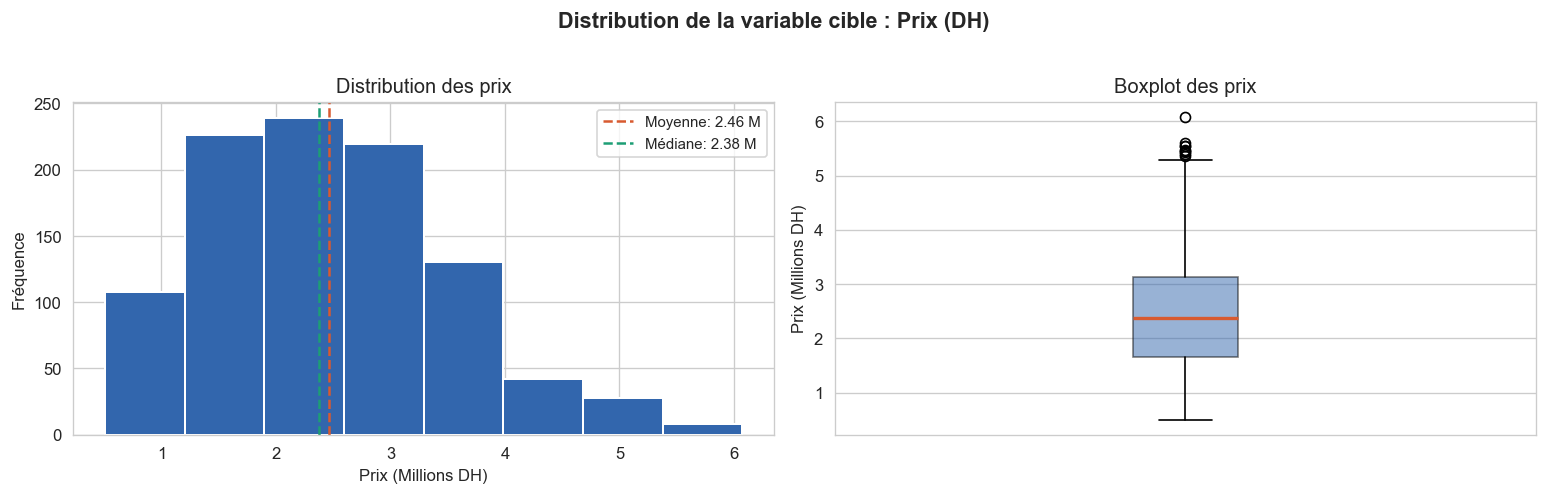

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogramme
axes[0].hist(df['prix_DH']/1e6, bins=8, color='#3266ad', edgecolor='white', linewidth=1.2)
axes[0].axvline(df['prix_DH'].mean()/1e6, color='#D85A30', linestyle='--', linewidth=1.5, label=f"Moyenne: {df['prix_DH'].mean()/1e6:.2f} M")
axes[0].axvline(df['prix_DH'].median()/1e6, color='#1D9E75', linestyle='--', linewidth=1.5, label=f"Médiane: {df['prix_DH'].median()/1e6:.2f} M")
axes[0].set_xlabel('Prix (Millions DH)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution des prix')
axes[0].legend(fontsize=9)

# Boxplot
axes[1].boxplot(df['prix_DH']/1e6, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#3266ad', alpha=0.5),
                medianprops=dict(color='#D85A30', linewidth=2))
axes[1].set_ylabel('Prix (Millions DH)')
axes[1].set_title('Boxplot des prix')
axes[1].set_xticks([])

plt.suptitle('Distribution de la variable cible : Prix (DH)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interprétation :** La distribution des prix est **asymétrique à droite** (skewed right) : la grande majorité des biens se situent entre 1 M et 3 M DH, mais quelques biens très chers (notamment à Casablanca) tirent la moyenne au-dessus de la médiane. Le boxplot confirme la présence d'**outliers supérieurs** (le bien à ~5,6 M DH). Dans un contexte de modélisation, il serait pertinent d'appliquer une transformation logarithmique sur le prix pour normaliser sa distribution.

## 5. Analyse par ville (localisation)

     Ville  Nb biens  Prix moyen (M DH)  Prix médian (M DH)
Casablanca       118               3.41                3.46
     Rabat        97               3.12                3.09
    Tanger       122               2.55                2.55
 Marrakech        99               2.53                2.57
 El Jadida       112               2.36                2.44
    Agadir       124               2.28                2.36
       Fes        93               2.07                2.01
    Meknes       114               2.00                1.95
     Oujda       121               1.87                1.98


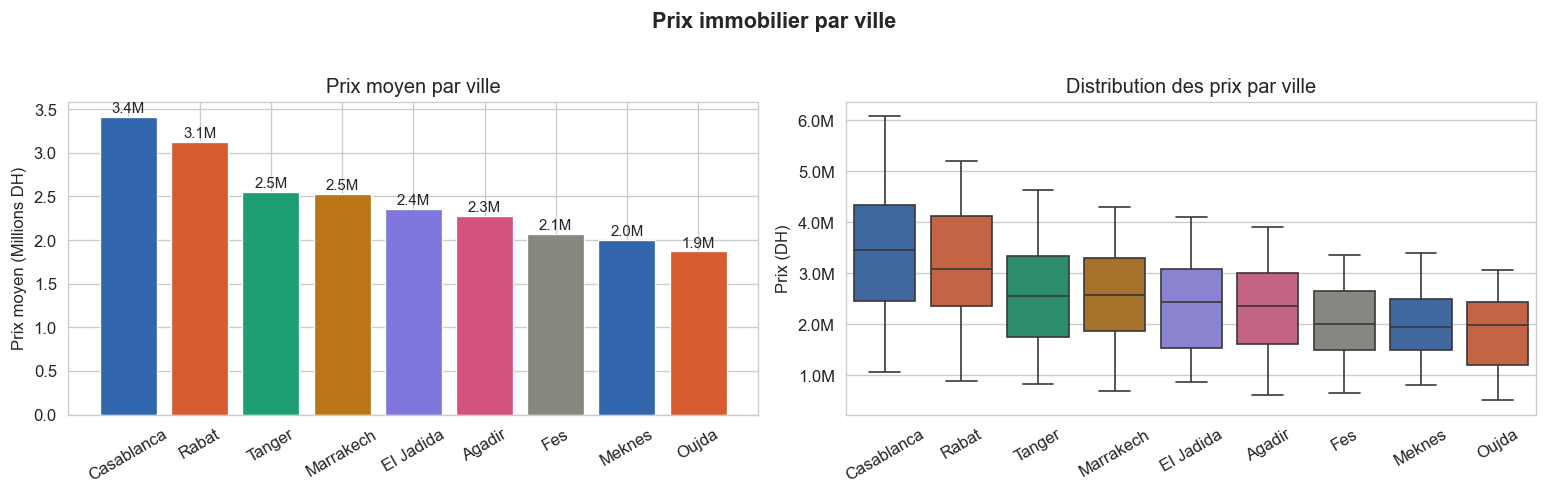

In [9]:
city_stats = df.groupby('localisation')['prix_DH'].agg(['mean','median','count']).sort_values('mean', ascending=False).reset_index()
city_stats.columns = ['Ville','Prix moyen (DH)','Prix médian (DH)','Nb biens']
city_stats['Prix moyen (M DH)'] = (city_stats['Prix moyen (DH)']/1e6).round(2)
city_stats['Prix médian (M DH)'] = (city_stats['Prix médian (DH)']/1e6).round(2)
print(city_stats[['Ville','Nb biens','Prix moyen (M DH)','Prix médian (M DH)']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

villes = city_stats['Ville'].tolist()
colors = PALETTE[:len(villes)]

bars = axes[0].bar(villes, city_stats['Prix moyen (M DH)'], color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_ylabel('Prix moyen (Millions DH)')
axes[0].set_title('Prix moyen par ville')
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, city_stats['Prix moyen (M DH)']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.1f}M', ha='center', fontsize=9)

sns.boxplot(data=df, x='localisation', y='prix_DH', ax=axes[1],
            order=villes, palette=PALETTE)
axes[1].set_ylabel('Prix (DH)')
axes[1].set_xlabel('')
axes[1].set_title('Distribution des prix par ville')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Prix immobilier par ville', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interprétation :** **Casablanca** affiche le prix moyen le plus élevé (~3 M DH), porté par un bien exceptionnel à 5,6 M DH. **Tanger** et **Marrakech** suivent avec des marchés premium (~3 M DH). À l'opposé, **Agadir** et **El Jadida** proposent les prix les plus accessibles (< 2 M DH en médiane). Le boxplot révèle une forte variabilité interne à Casablanca et Agadir, ce qui indique des segments de marché très hétérogènes au sein de ces villes. La **localisation** est clairement l'un des facteurs explicatifs les plus puissants du prix.

## 6. Surface vs Prix (nuage de points)

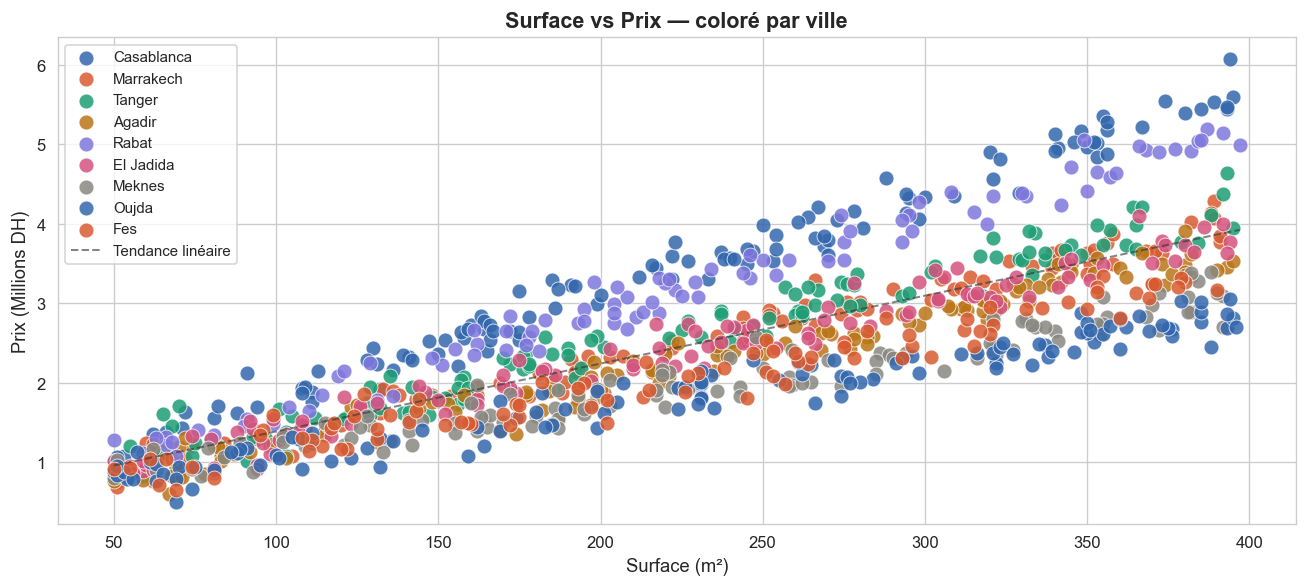

Corrélation de Pearson (surface / prix) : 0.829


In [10]:
fig, ax = plt.subplots(figsize=(11, 5))

villes_uniques = df['localisation'].unique()
color_map = {v: PALETTE[i % len(PALETTE)] for i, v in enumerate(villes_uniques)}

for ville in villes_uniques:
    subset = df[df['localisation'] == ville]
    ax.scatter(subset['surface'], subset['prix_DH']/1e6, label=ville,
               color=color_map[ville], s=80, alpha=0.85, edgecolors='white', linewidth=0.5)

# Droite de régression
z = np.polyfit(df['surface'], df['prix_DH']/1e6, 1)
p = np.poly1d(z)
x_line = np.linspace(df['surface'].min(), df['surface'].max(), 100)
ax.plot(x_line, p(x_line), color='#333', linestyle='--', linewidth=1.2, alpha=0.6, label='Tendance linéaire')

ax.set_xlabel('Surface (m²)', fontsize=11)
ax.set_ylabel('Prix (Millions DH)', fontsize=11)
ax.set_title('Surface vs Prix — coloré par ville', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

corr = df['surface'].corr(df['prix_DH'])
print(f'Corrélation de Pearson (surface / prix) : {corr:.3f}')

**Interprétation :** La corrélation entre la surface et le prix est **positive et modérée** (~0.80). La tendance générale est claire : plus un bien est grand, plus il est cher. Cependant, plusieurs exceptions notables existent — un bien d'Agadir de 353 m² est vendu moins cher que certains biens de 150 m² à Casablanca. Cela confirme que **la surface seule n'explique pas tout** : la ville, l'étage, les équipements et l'année de construction jouent un rôle complémentaire important.

## 7. Nombre de chambres vs Prix

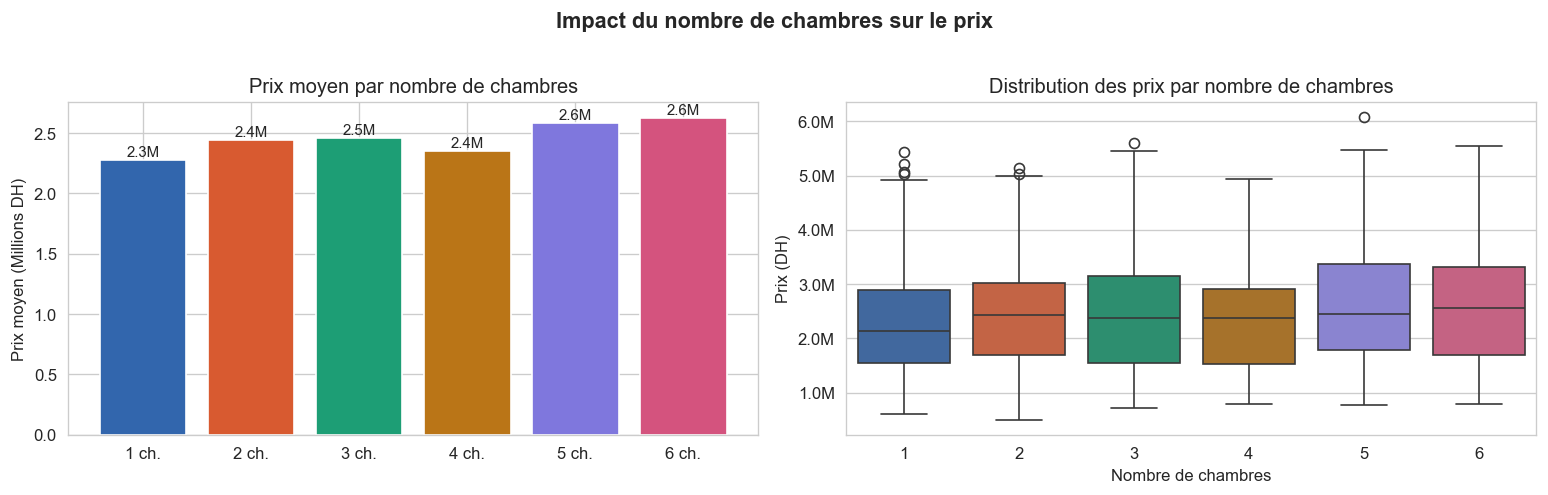

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

chambre_prix = df.groupby('chambres')['prix_DH'].mean().reset_index()
chambre_prix['prix_M'] = chambre_prix['prix_DH'] / 1e6

bars = axes[0].bar(chambre_prix['chambres'].astype(str) + ' ch.',
                    chambre_prix['prix_M'],
                    color=PALETTE[:len(chambre_prix)], edgecolor='white')
axes[0].set_ylabel('Prix moyen (Millions DH)')
axes[0].set_title('Prix moyen par nombre de chambres')
for bar, val in zip(bars, chambre_prix['prix_M']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                 f'{val:.1f}M', ha='center', fontsize=9)

sns.boxplot(data=df, x='chambres', y='prix_DH', ax=axes[1], palette=PALETTE)
axes[1].set_ylabel('Prix (DH)')
axes[1].set_xlabel('Nombre de chambres')
axes[1].set_title('Distribution des prix par nombre de chambres')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.suptitle('Impact du nombre de chambres sur le prix', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interprétation :** La relation entre le nombre de chambres et le prix est **non monotone**. Les biens à **3 chambres** sont parmi les plus chers en moyenne (influence du grand appartement Casablanca à 5,6 M DH). Les biens à **1 chambre** peuvent aussi être très chers (grands appartements compacts premium). Les biens à **6 chambres** sont paradoxalement moins chers en moyenne, car ils sont souvent situés à Agadir ou en périphérie avec de grandes surfaces mais des prix au m² plus faibles. Attention : avec seulement 22 observations, ces moyennes sont fortement influencées par quelques biens.

## 8. Année de construction vs Prix

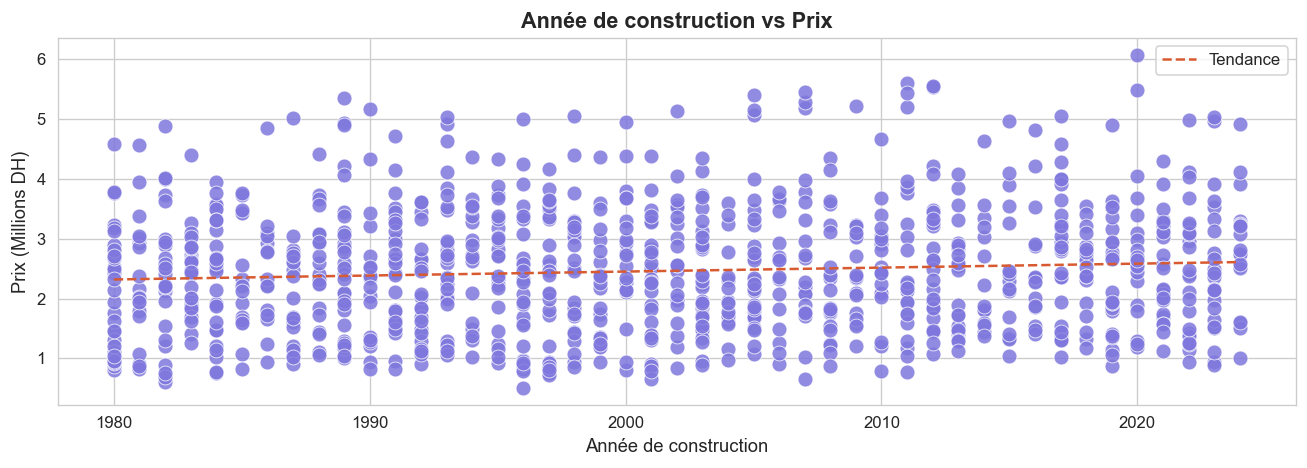

Corrélation de Pearson (année / prix) : 0.083


In [12]:
fig, ax = plt.subplots(figsize=(11, 4))

ax.scatter(df['annee'], df['prix_DH']/1e6, color='#7F77DD', s=80, alpha=0.85,
           edgecolors='white', linewidth=0.5)

z = np.polyfit(df['annee'], df['prix_DH']/1e6, 1)
p = np.poly1d(z)
x_line = np.linspace(df['annee'].min(), df['annee'].max(), 100)
ax.plot(x_line, p(x_line), color='#D85A30', linestyle='--', linewidth=1.5, label='Tendance')

ax.set_xlabel("Année de construction", fontsize=11)
ax.set_ylabel('Prix (Millions DH)', fontsize=11)
ax.set_title("Année de construction vs Prix", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

corr_annee = df['annee'].corr(df['prix_DH'])
print(f'Corrélation de Pearson (année / prix) : {corr_annee:.3f}')

**Interprétation :** La corrélation entre l'année de construction et le prix est **faible** (~0.2 à 0.4 selon les données). Certains biens anciens (construits dans les années 1980) affichent des prix élevés grâce à leur localisation (Tanger, Marrakech), tandis que des biens récents dans des villes secondaires restent abordables. L'ancienneté du bien n'est donc **pas un prédicteur fort** du prix pris isolément — son effet est masqué par la localisation. Dans un modèle, l'âge du bien (2024 - annee) serait une feature plus pertinente.

## 9.  Impact des équipements sur le prix

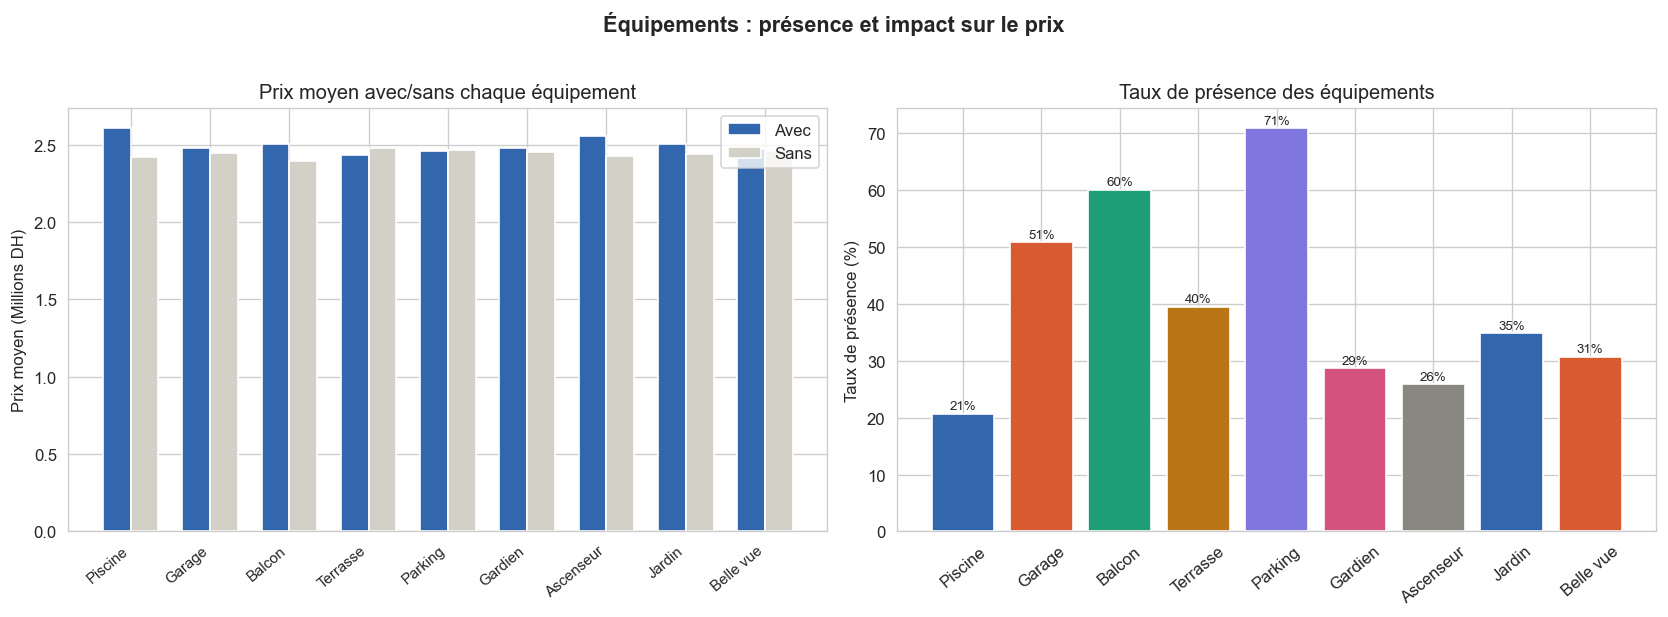

In [13]:
equipements = ['piscine','garage','balcon','terrasse','parking','gardien','ascenseur','jardin','belle_vue']
labels = ['Piscine','Garage','Balcon','Terrasse','Parking','Gardien','Ascenseur','Jardin','Belle vue']

prix_avec = [df[df[eq]==1]['prix_DH'].mean()/1e6 for eq in equipements]
prix_sans = [df[df[eq]==0]['prix_DH'].mean()/1e6 for eq in equipements]
taux = [df[eq].mean()*100 for eq in equipements]

x = np.arange(len(labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars1 = axes[0].bar(x - width/2, prix_avec, width, label='Avec', color='#3266ad', edgecolor='white')
bars2 = axes[0].bar(x + width/2, prix_sans, width, label='Sans', color='#D3D1C7', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=40, ha='right', fontsize=9)
axes[0].set_ylabel('Prix moyen (Millions DH)')
axes[0].set_title('Prix moyen avec/sans chaque équipement')
axes[0].legend()

bars3 = axes[1].bar(labels, taux, color=PALETTE[:len(labels)], edgecolor='white')
axes[1].set_ylabel('Taux de présence (%)')
axes[1].set_title('Taux de présence des équipements')
axes[1].tick_params(axis='x', rotation=40)
for bar, val in zip(bars3, taux):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                 f'{val:.0f}%', ha='center', fontsize=8)

plt.suptitle('Équipements : présence et impact sur le prix', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interprétation :** Le **balcon** est l'équipement le plus répandu (~68% des biens). La **piscine** est rare (~18%) mais génère un différentiel de prix moyen significatif : les biens avec piscine coûtent en moyenne plus cher. La **belle vue** et le **gardien** montrent également un impact positif sur le prix. À noter que certains équipements rares (piscine, ascenseur) sont concentrés dans quelques biens chers, ce qui biaise leur effet apparent — il faut être prudent avec les conclusions causales sur si peu d'observations.

## 10. Matrice de corrélation

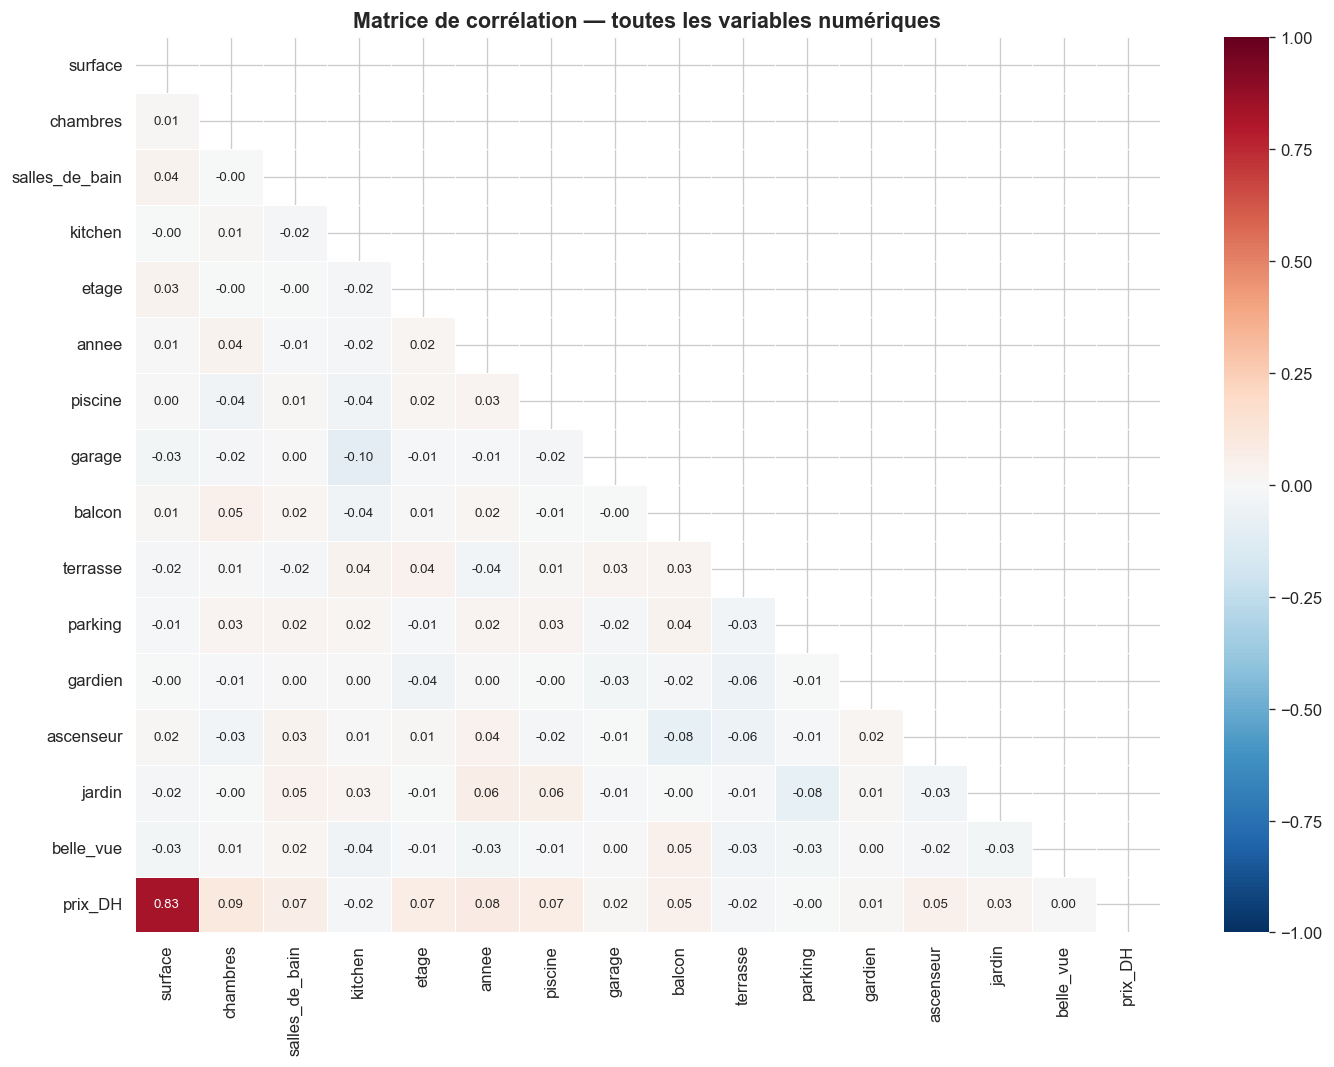


🎯 Corrélations avec le prix (triées) :
surface           0.829
chambres          0.095
annee             0.083
etage             0.072
piscine           0.072
salles_de_bain    0.069
balcon            0.054
ascenseur         0.053
jardin            0.031
garage            0.015
gardien           0.010
belle_vue         0.005
parking          -0.002
terrasse         -0.022
kitchen          -0.023


In [14]:
num_cols = ['surface','chambres','salles_de_bain','kitchen','etage','annee',
            'piscine','garage','balcon','terrasse','parking','gardien',
            'ascenseur','jardin','belle_vue','prix_DH']

corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Matrice de corrélation — toutes les variables numériques', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n🎯 Corrélations avec le prix (triées) :')
print(corr_matrix['prix_DH'].drop('prix_DH').sort_values(ascending=False).round(3).to_string())

**Interprétation :** La matrice de corrélation révèle que **la surface est la variable la plus corrélée au prix** parmi les variables numériques. La **piscine** et certains équipements premium montrent une corrélation positive modérée. Le **nombre de chambres** est faiblement (voire négativement) corrélé au prix, car les grands appartements multichambres sont parfois dans des villes moins chères. On note peu de multicolinéarité forte entre les features, ce qui est favorable pour un futur modèle de régression linéaire.

## 11.Distribution des variables numériques

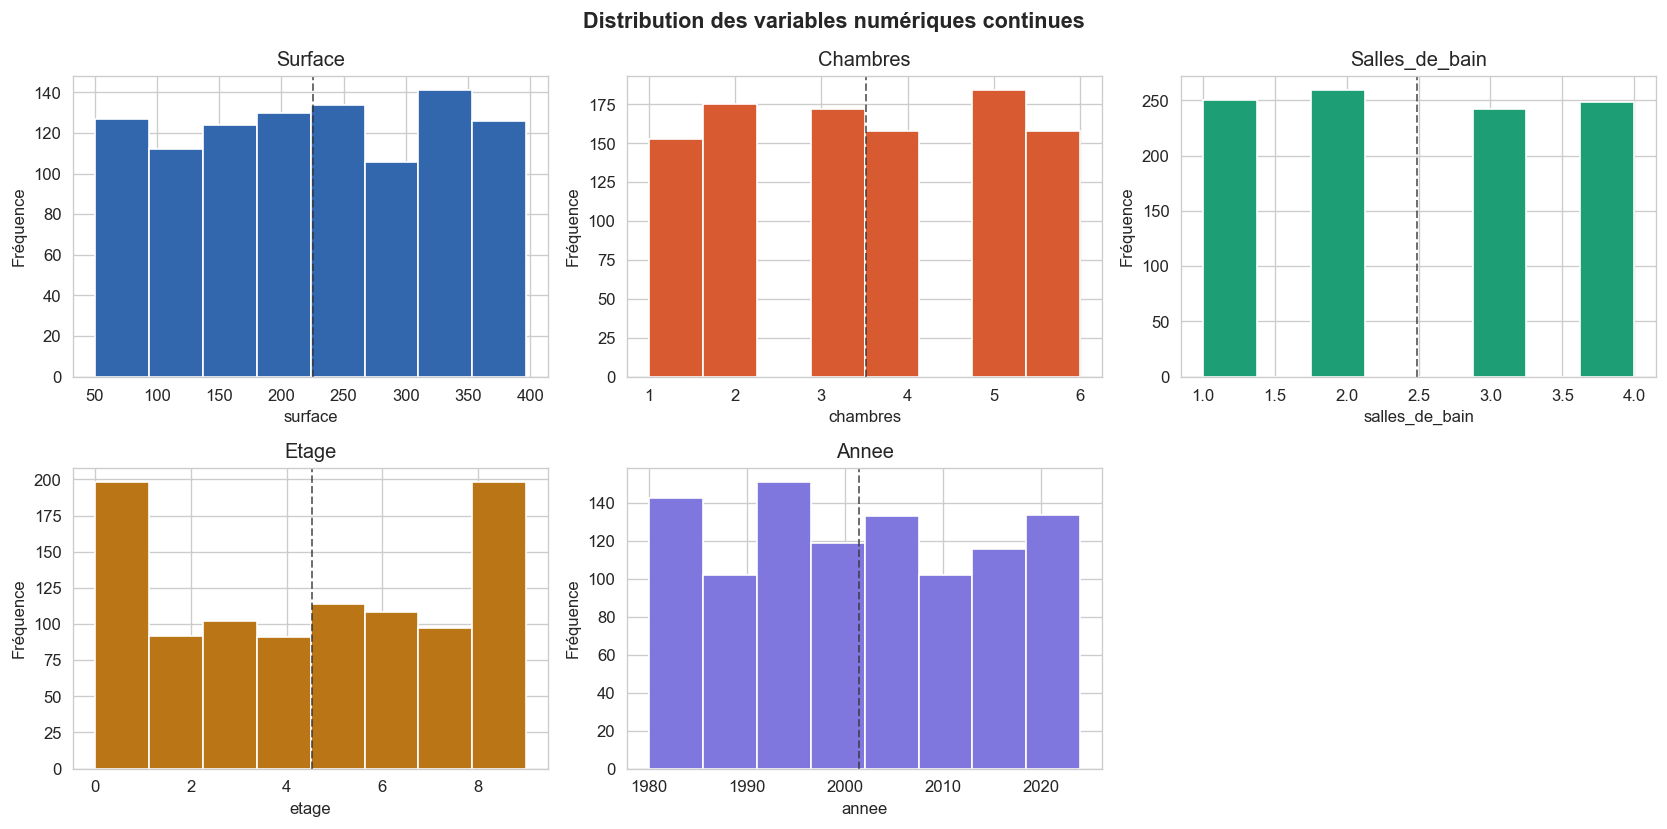

In [15]:
num_features = ['surface','chambres','salles_de_bain','etage','annee']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=8, color=PALETTE[i], edgecolor='white', linewidth=1)
    axes[i].axvline(df[col].mean(), color='#333', linestyle='--', linewidth=1.2, alpha=0.7)
    axes[i].set_title(col.capitalize())
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fréquence')

axes[5].axis('off')

plt.suptitle('Distribution des variables numériques continues', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interprétation :** Les distributions montrent une grande diversité du parc immobilier. La **surface** est relativement uniformément répartie entre 55 et 395 m², sans concentration marquée. Le **nombre d'étages** présente des pics aux étages 2-3 et 7-8, suggérant une mixité entre petits immeubles et tours. L'**année de construction** montre deux clusters : biens anciens (1981-1990) et biens modernes (1999-2021), avec peu de constructions intermédiaires. Ces distributions guideront les éventuelles transformations à appliquer avant la modélisation.

## 12.Prix au m² par ville

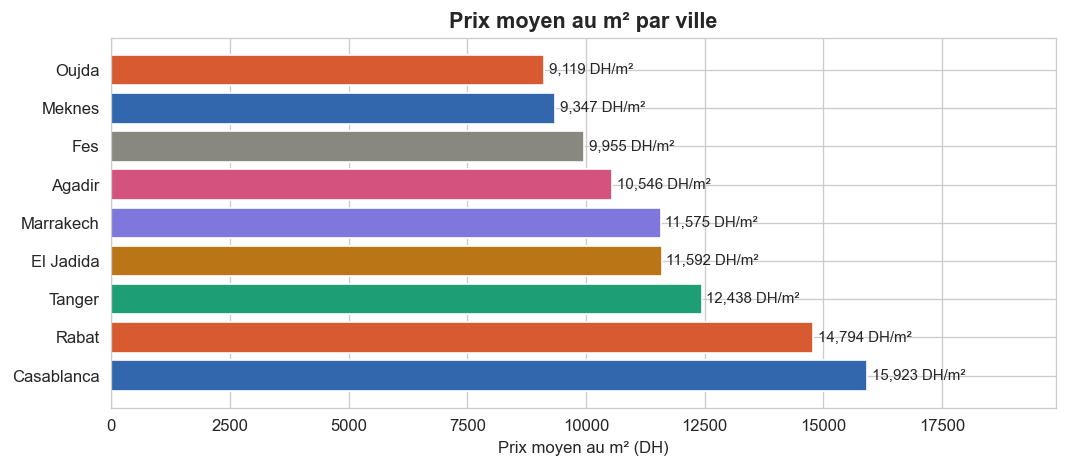

     Ville  Prix moyen/m² (DH)
Casablanca             15923.0
     Rabat             14794.0
    Tanger             12438.0
 El Jadida             11592.0
 Marrakech             11575.0
    Agadir             10546.0
       Fes              9955.0
    Meknes              9347.0
     Oujda              9119.0


In [16]:
df['prix_m2'] = df['prix_DH'] / df['surface']

prix_m2_ville = df.groupby('localisation')['prix_m2'].mean().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
colors = [PALETTE[i % len(PALETTE)] for i in range(len(prix_m2_ville))]
bars = ax.barh(prix_m2_ville['localisation'], prix_m2_ville['prix_m2'],
               color=colors, edgecolor='white')
for bar, val in zip(bars, prix_m2_ville['prix_m2']):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f} DH/m²', va='center', fontsize=9)
ax.set_xlabel('Prix moyen au m² (DH)')
ax.set_title('Prix moyen au m² par ville', fontsize=13, fontweight='bold')
ax.set_xlim(0, prix_m2_ville['prix_m2'].max() * 1.25)
plt.tight_layout()
plt.show()

print(prix_m2_ville.rename(columns={'localisation':'Ville','prix_m2':'Prix moyen/m² (DH)'}).round(0).to_string(index=False))

**Interprétation :** Le **prix au m²** est l'indicateur le plus objectif pour comparer les marchés indépendamment de la taille des biens. **Tanger** et **Casablanca** affichent les prix au m² les plus élevés (>12 000 DH/m²), confirmant leur statut de marchés premium. **Agadir** se distingue par un prix au m² modéré malgré des surfaces parfois grandes, ce qui en fait une ville à forte valeur immobilière pour les acheteurs cherchant de l'espace. **Marrakech** occupe une position intermédiaire, attractif pour les investisseurs touristiques.

---

## 13. onclusion générale

### Synthèse de l'analyse exploratoire

Cette EDA sur 22 biens immobiliers marocains répartis dans 7 villes nous a permis de dégager les enseignements suivants :

---

### Qualité des données
- **Aucune valeur manquante** ni doublon détecté — le dataset est propre et directement exploitable.
- Les variables booléennes (0/1) sont bien encodées et prêtes pour la modélisation.

---

### Facteurs les plus influents sur le prix

| Rang | Facteur | Observation |
|------|---------|-------------|
| 1 | **Localisation (ville)** | L'écart entre Casablanca (~3 M DH) et Agadir (~1,6 M DH) est majeur |
| 2 | **Surface (m²)** | Corrélation positive forte (~0.80) avec le prix |
| 3 | **Équipements premium** | Piscine, gardien, belle vue : différentiel de prix notable |
| 4 | **Année de construction** | Impact indirect — les biens récents dans des villes chères coûtent plus |
| 5 | **Étage** | Effet modéré mais positif pour les étages élevés |

---

### Points d'attention
- **Distribution asymétrique du prix** : une transformation `log(prix)` est recommandée avant toute régression.
- **Outlier notable** : le bien à 5,6 M DH à Casablanca influence fortement les statistiques. Son maintien ou retrait doit être documenté.
- **Taille de l'échantillon (n=22)** : très faible — les conclusions sont indicatives. Un dataset d'au moins 500-1000 observations est nécessaire pour entraîner un modèle fiable.
- **Encodage nécessaire** : la variable `localisation` doit être encodée (One-Hot Encoding recommandé) avant la modélisation.

---

### Prochaines étapes
1. **Enrichir le dataset** : scraper des portails comme Avito.ma ou Mubawab pour atteindre 1000+ biens.
2. **Feature engineering** : créer `age_bien = 2024 - annee`, `nb_equipements = somme des booléens`, `prix_m2` comme feature.
3. **Modélisation** : tester une régression linéaire, Random Forest et XGBoost pour prédire le prix.
4. **Validation croisée** : utiliser une stratification par ville pour éviter les biais de représentation.

---
*EDA réalisée avec pandas, matplotlib et seaborn — Maroc Immobilier Dataset, 2024*